<a href="https://colab.research.google.com/github/DMariano0912/DeepLearningECGR4106/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Problem 1:

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import requests


torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Dataset:

In [ ]:
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

Vocab Setup:

In [ ]:

chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

encoded_text = torch.tensor([char_to_idx[ch] for ch in text], dtype=torch.long)

print("Text length:", len(encoded_text))
print("Vocabulary size:", vocab_size)

class CharDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+1:idx+self.seq_length+1]
        return x, y

Text length: 2391
Vocabulary size: 45


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len].to(x.device)

class CharTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)

        seq_len = x.size(1)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(x.device)

        x = self.transformer(x, mask=mask)
        logits = self.fc(x)

        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Training:

In [ ]:
def train_and_validate(seq_length, epochs=40, batch_size=32, lr=0.001):
    dataset = CharDataset(encoded_text, seq_length)

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    model = CharTransformer(vocab_size).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(x)

            loss = criterion(
                outputs.reshape(-1, vocab_size),
                y.reshape(-1)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                outputs = model(x)
                predictions = torch.argmax(outputs, dim=-1)

                correct += (predictions == y).sum().item()
                total += y.numel()

        val_acc = correct / total
        val_accuracies.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Seq Len {seq_length} | Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

    end_time = time.time()
    training_time = end_time - start_time

    results = {
        "Sequence Length": seq_length,
        "Final Training Loss": train_losses[-1],
        "Final Validation Accuracy": val_accuracies[-1],
        "Training Time (sec)": training_time,
        "Parameter Count": count_parameters(model),
        "Approx. Complexity": f"O({seq_length}^2 * d_model)"
    }

    return model, train_losses, val_accuracies, results

Sequence Length(s):

In [ ]:
sequence_lengths = [10, 20, 30]

all_results = []
all_losses = {}
all_accuracies = {}

for seq_len in sequence_lengths:
    print("\nTraining Transformer with sequence length:", seq_len)

    model, losses, accuracies, results = train_and_validate(
        seq_length=seq_len,
        epochs=40,
        batch_size=32,
        lr=0.001
    )

    all_results.append(results)
    all_losses[seq_len] = losses
    all_accuracies[seq_len] = accuracies

results_df = pd.DataFrame(all_results)
results_df


Training Transformer with sequence length: 10
Seq Len 10 | Epoch 10/40 | Loss: 1.5847 | Val Acc: 0.5528
Seq Len 10 | Epoch 20/40 | Loss: 1.2761 | Val Acc: 0.6405
Seq Len 10 | Epoch 30/40 | Loss: 1.1324 | Val Acc: 0.6771
Seq Len 10 | Epoch 40/40 | Loss: 1.0579 | Val Acc: 0.7113

Training Transformer with sequence length: 20
Seq Len 20 | Epoch 10/40 | Loss: 1.3378 | Val Acc: 0.6719
Seq Len 20 | Epoch 20/40 | Loss: 1.0049 | Val Acc: 0.7862
Seq Len 20 | Epoch 30/40 | Loss: 0.8544 | Val Acc: 0.8213
Seq Len 20 | Epoch 40/40 | Loss: 0.7759 | Val Acc: 0.8454

Training Transformer with sequence length: 30
Seq Len 30 | Epoch 10/40 | Loss: 1.2747 | Val Acc: 0.6899
Seq Len 30 | Epoch 20/40 | Loss: 0.9024 | Val Acc: 0.8292
Seq Len 30 | Epoch 30/40 | Loss: 0.7560 | Val Acc: 0.8677
Seq Len 30 | Epoch 40/40 | Loss: 0.6790 | Val Acc: 0.8825


,Sequence Length,Final Training Loss,Final Validation Accuracy,Training Time (sec),Parameter Count,Approx. Complexity
0,10,1.057901,0.711321,17.947751,72749,O(10^2 * d_model)
1,20,0.775850,0.845368,17.189618,72749,O(20^2 * d_model)
2,30,0.678959,0.882452,16.942864,72749,O(30^2 * d_model)


Plots:

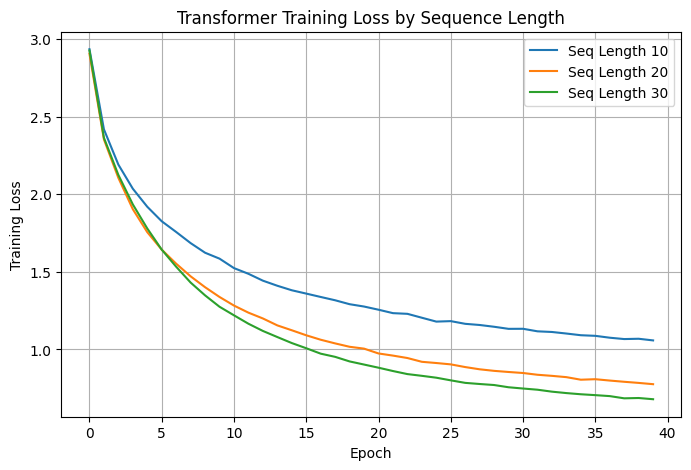

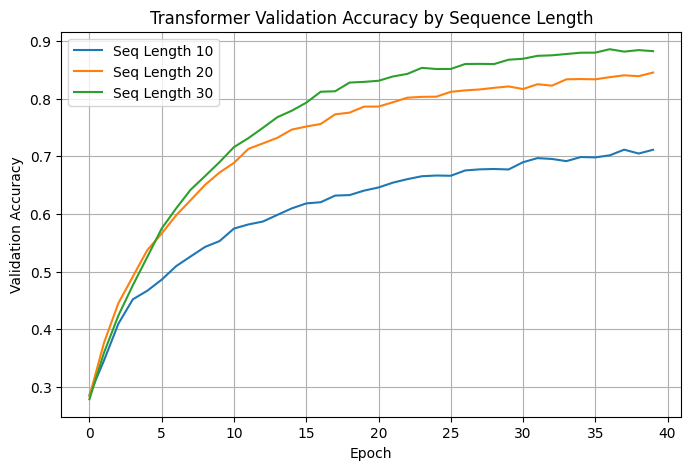

,Sequence Length,Final Training Loss,Final Validation Accuracy,Training Time (sec),Parameter Count,Approx. Complexity
0,10,1.057901,0.711321,17.947751,72749,O(10^2 * d_model)
1,20,0.775850,0.845368,17.189618,72749,O(20^2 * d_model)
2,30,0.678959,0.882452,16.942864,72749,O(30^2 * d_model)


In [ ]:
plt.figure(figsize=(8, 5))

for seq_len in sequence_lengths:
    plt.plot(all_losses[seq_len], label=f"Seq Length {seq_len}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer Training Loss by Sequence Length")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

for seq_len in sequence_lengths:
    plt.plot(all_accuracies[seq_len], label=f"Seq Length {seq_len}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Transformer Validation Accuracy by Sequence Length")
plt.legend()
plt.grid(True)
plt.show()

results_df


##Problem 2:

Shakespeare Download:

In [89]:

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text

chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

encoded_text = torch.tensor([char_to_int[ch] for ch in text], dtype=torch.long)

print("Dataset length:", len(encoded_text))
print("Vocabulary size:", vocab_size)

Dataset length: 1115394
Vocabulary size: 65


DataLoader Function:

In [90]:
class CharDataset(Dataset):
    def __init__(self, encoded_text, sequence_length):
        self.encoded_text = encoded_text
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.encoded_text) - self.sequence_length

    def __getitem__(self, index):
        sequence = self.encoded_text[index:index+self.sequence_length]
        target = self.encoded_text[index+self.sequence_length]
        return sequence, target


def create_loaders(sequence_length, batch_size=128):
    dataset = CharDataset(encoded_text, sequence_length)

    train_size = int(len(dataset) * 0.8)
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
    val_loader = DataLoader(val_dataset, shuffle=False, batch_size=batch_size)

    return train_loader, val_loader

class PositionalEncoding(nn.Module):
    def __init__(self, hidden_size, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, hidden_size)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, hidden_size, 2) * (-math.log(10000.0) / hidden_size)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

Model Setup:

In [91]:
class ShakespeareTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        hidden_size=128,
        num_heads=2,
        num_blocks=2,
        dropout=0.2
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_blocks
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)

        seq_len = x.size(1)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(x.device)

        x = self.transformer(x, mask=mask)

        x = x[:, -1, :]

        logits = self.fc(x)

        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def approximate_complexity(sequence_length, hidden_size, num_blocks):
    return f"O({num_blocks} * {sequence_length}² * {hidden_size})"


def calculate_perplexity(loss):
    return math.exp(loss)


def evaluate_model(model, val_loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    inference_start = time.time()

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == y).sum().item()
            total += y.size(0)

    inference_time = time.time() - inference_start

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total

    return avg_loss, accuracy, inference_time

Training:

In [92]:
def train_transformer(
    sequence_length,
    hidden_size=128,
    num_heads=2,
    num_blocks=2,
    epochs=10,
    batch_size=128,
    lr=0.001
):
    train_loader, val_loader = create_loaders(sequence_length, batch_size)

    model = ShakespeareTransformer(
        vocab_size=vocab_size,
        hidden_size=hidden_size,
        num_heads=num_heads,
        num_blocks=num_blocks
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        val_loss, val_accuracy, _ = evaluate_model(model, val_loader, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    training_time = time.time() - start_time

    final_val_loss, final_val_acc, inference_time = evaluate_model(
        model, val_loader, criterion
    )

    results = {
        "Sequence Length": sequence_length,
        "Hidden Size": hidden_size,
        "Transformer Blocks": num_blocks,
        "Heads": num_heads,
        "Final Training Loss": train_losses[-1],
        "Final Validation Loss": final_val_loss,
        "Final Validation Accuracy": final_val_acc,
        "Perplexity": calculate_perplexity(final_val_loss),
        "Training Time (sec)": training_time,
        "Inference Time (sec)": inference_time,
        "Parameter Count": count_parameters(model),
        "Approx Complexity": approximate_complexity(sequence_length, hidden_size, num_blocks)
    }

    return model, train_losses, val_losses, val_accuracies, results



Transformer Model Without Changes:

In [ ]:
base_sequence_lengths = [20, 30]

base_results = []
base_train_losses = {}
base_val_accuracies = {}

for seq_len in base_sequence_lengths:
    print("\nTraining Base Transformer with sequence length:", seq_len)

    model, train_losses, val_losses, val_accuracies, results = train_transformer(
        sequence_length=seq_len,
        hidden_size=128,
        num_heads=2,
        num_blocks=2,
        epochs=10,
        batch_size=128,
        lr=0.001
    )

    base_results.append(results)
    base_train_losses[seq_len] = train_losses
    base_val_accuracies[seq_len] = val_accuracies

base_results_df = pd.DataFrame(base_results)
base_results_df



plt.figure(figsize=(8, 5))

for seq_len in base_sequence_lengths:
    plt.plot(base_train_losses[seq_len], label=f"Seq Length {seq_len}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

for seq_len in base_sequence_lengths:
    plt.plot(base_val_accuracies[seq_len], label=f"Seq Length {seq_len}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Transformer Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

HyperParameter Changes:

In [94]:
hyperparameter_configs = [
    {"num_blocks": 1, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 1, "num_heads": 4, "hidden_size": 128},
    {"num_blocks": 2, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 2, "num_heads": 4, "hidden_size": 128},
    {"num_blocks": 4, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 4, "num_heads": 4, "hidden_size": 128},
]

hyperparameter_results = []

for config in hyperparameter_configs:
    print("\nRunning Hyperparameter Experiment:")
    print(config)

    model, train_losses, val_losses, val_accuracies, results = train_transformer(
        sequence_length=30,
        hidden_size=config["hidden_size"],
        num_heads=config["num_heads"],
        num_blocks=config["num_blocks"],
        epochs=5,
        batch_size=256,
        lr=0.001
    )

    hyperparameter_results.append(results)

hyperparameter_results_df = pd.DataFrame(hyperparameter_results)

hyperparameter_results_df

clean_hyperparameter_results_df = hyperparameter_results_df[
    [
        "Transformer Blocks",
        "Heads",
        "Hidden Size",
        "Sequence Length",
        "Final Training Loss",
        "Final Validation Loss",
        "Final Validation Accuracy",
        "Perplexity",
        "Training Time (sec)",
        "Inference Time (sec)",
        "Parameter Count",
        "Approx Complexity"
    ]
]

clean_hyperparameter_results_df


Running Hyperparameter Experiment:
{'num_blocks': 1, 'num_heads': 2, 'hidden_size': 128}
Epoch 1/5 | Train Loss: 2.1402 | Val Loss: 1.8849 | Val Acc: 0.4453


KeyboardInterrupt: 

With Sequence Length 50:

Epoch 1/10 | Train Loss: 2.0673 | Val Loss: 1.8255 | Val Acc: 0.4568
Epoch 2/10 | Train Loss: 1.8978 | Val Loss: 1.7450 | Val Acc: 0.4754
Epoch 3/10 | Train Loss: 1.8477 | Val Loss: 1.7158 | Val Acc: 0.4837
Epoch 4/10 | Train Loss: 1.8077 | Val Loss: 1.6917 | Val Acc: 0.4875
Epoch 5/10 | Train Loss: 1.7754 | Val Loss: 1.6583 | Val Acc: 0.4946
Epoch 6/10 | Train Loss: 1.7526 | Val Loss: 1.6336 | Val Acc: 0.5013
Epoch 7/10 | Train Loss: 1.7291 | Val Loss: 1.6155 | Val Acc: 0.5087
Epoch 8/10 | Train Loss: 1.7197 | Val Loss: 1.6064 | Val Acc: 0.5090
Epoch 9/10 | Train Loss: 1.7023 | Val Loss: 1.5879 | Val Acc: 0.5144
Epoch 10/10 | Train Loss: 1.6873 | Val Loss: 1.5854 | Val Acc: 0.5168


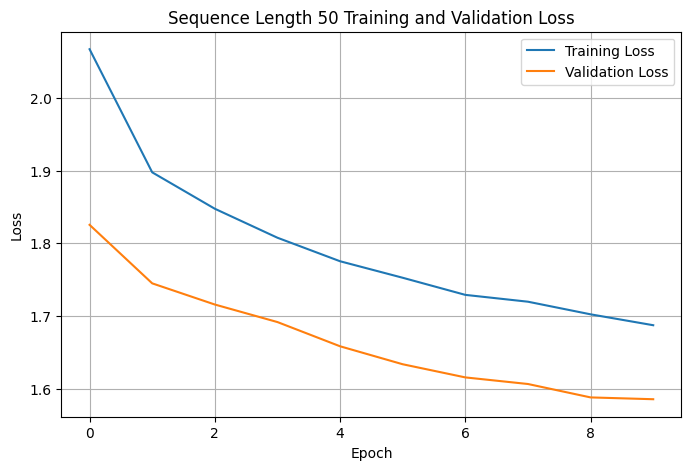

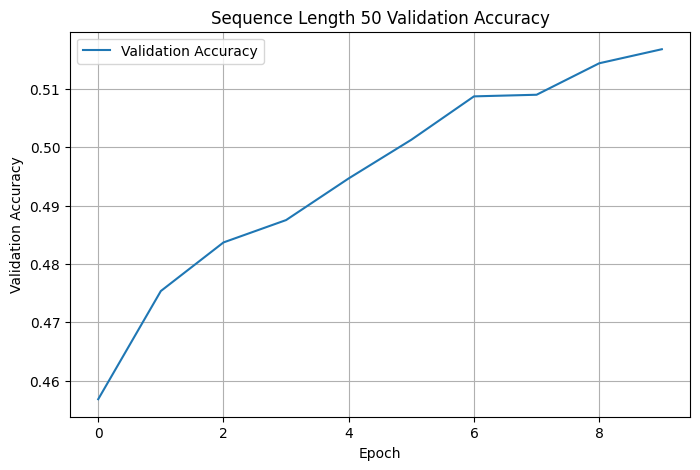

,Sequence Length,Transformer Blocks,Heads,Hidden Size,Final Training Loss,Final Validation Loss,Final Validation Accuracy,Perplexity,Training Time (sec),Inference Time (sec),Parameter Count,Approx Complexity
0,50,2,4,256,1.687305,1.585429,0.516782,4.881387,1025.185316,8.948147,1612865,O(2 * 50² * 256)


In [95]:
seq50_model, seq50_train_losses, seq50_val_losses, seq50_val_accuracies, seq50_results = train_transformer(
    sequence_length=50,
    hidden_size=256,
    num_heads=4,
    num_blocks=2,
    epochs=10,
    batch_size=128,
    lr=0.001
)

seq50_results_df = pd.DataFrame([seq50_results])
seq50_results_df

plt.figure(figsize=(8, 5))

plt.plot(seq50_train_losses, label="Training Loss")
plt.plot(seq50_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sequence Length 50 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(seq50_val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Sequence Length 50 Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

seq50_results_df = pd.DataFrame([seq50_results])

seq50_results_df = seq50_results_df[
    [
        "Sequence Length",
        "Transformer Blocks",
        "Heads",
        "Hidden Size",
        "Final Training Loss",
        "Final Validation Loss",
        "Final Validation Accuracy",
        "Perplexity",
        "Training Time (sec)",
        "Inference Time (sec)",
        "Parameter Count",
        "Approx Complexity"
    ]
]

seq50_results_df

##Problem 3:

Importing Text:

In [47]:
from google.colab import files

uploaded = files.upload()

DATA_PATH = "vast_english_french.txt"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")

pairs = []

for line in lines:
    parts = line.split("\t")

    if len(parts) >= 2:
        eng = parts[0].strip().lower()
        fra = parts[1].strip().lower()
        pairs.append((eng, fra))

print("Total sentence pairs:", len(pairs))

Saving vast_english_french.txt to vast_english_french (1).txt
Total sentence pairs: 555


Train 80/20 Split:

In [64]:
torch.manual_seed(42)

train_size = int(0.8 * len(pairs))
val_size = len(pairs) - train_size

train_pairs, val_pairs = torch.utils.data.random_split(
    pairs,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_pairs = list(train_pairs)
val_pairs = list(val_pairs)

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

#Vocab Building
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

special_tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

def tokenize(sentence):
    return sentence.lower().strip().split()

def build_vocab(sentences, min_freq=1):
    freq = {}

    for sentence in sentences:
        for token in tokenize(sentence):
            freq[token] = freq.get(token, 0) + 1

    vocab = special_tokens.copy()

    for token, count in freq.items():
        if count >= min_freq:
            vocab.append(token)

    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    idx_to_word = {idx: word for word, idx in word_to_idx.items()}

    return word_to_idx, idx_to_word

eng_sentences = [pair[0] for pair in train_pairs]
fra_sentences = [pair[1] for pair in train_pairs]

eng_word_to_idx, eng_idx_to_word = build_vocab(eng_sentences)
fra_word_to_idx, fra_idx_to_word = build_vocab(fra_sentences)

eng_vocab_size = len(eng_word_to_idx)
fra_vocab_size = len(fra_word_to_idx)

PAD_IDX = fra_word_to_idx[PAD_TOKEN]
SOS_IDX = fra_word_to_idx[SOS_TOKEN]
EOS_IDX = fra_word_to_idx[EOS_TOKEN]
UNK_IDX = fra_word_to_idx[UNK_TOKEN]

print("English vocab size:", eng_vocab_size)
print("French vocab size:", fra_vocab_size)

Training pairs: 444
Validation pairs: 111
English vocab size: 903
French vocab size: 1001


Encoding:

In [65]:
MAX_LEN = 25

def encode_sentence(sentence, word_to_idx, max_len=MAX_LEN):
    tokens = tokenize(sentence)

    encoded = [word_to_idx.get(token, word_to_idx[UNK_TOKEN]) for token in tokens]
    encoded = encoded[:max_len - 2]

    encoded = [word_to_idx[SOS_TOKEN]] + encoded + [word_to_idx[EOS_TOKEN]]

    while len(encoded) < max_len:
        encoded.append(word_to_idx[PAD_TOKEN])

    return encoded

class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        eng, fra = self.pairs[index]

        src = encode_sentence(eng, eng_word_to_idx)
        tgt = encode_sentence(fra, fra_word_to_idx)

        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

batch_size = 64

train_dataset = TranslationDataset(train_pairs)
val_dataset = TranslationDataset(val_pairs)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

class TranslationPositionalEncoding(nn.Module):
    def __init__(self, hidden_size, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, hidden_size)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, hidden_size, 2) * (-math.log(10000.0) / hidden_size)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

Model:

In [66]:

class TransformerTranslator(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        hidden_size=128,
        num_heads=2,
        num_blocks=2,
        dropout=0.2
    ):
        super().__init__()

        self.hidden_size = hidden_size

        self.src_embedding = nn.Embedding(src_vocab_size, hidden_size)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, hidden_size)

        self.src_pos_encoding = TranslationPositionalEncoding(hidden_size)
        self.tgt_pos_encoding = TranslationPositionalEncoding(hidden_size)

        self.transformer = nn.Transformer(
            d_model=hidden_size,
            nhead=num_heads,
            num_encoder_layers=num_blocks,
            num_decoder_layers=num_blocks,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(hidden_size, tgt_vocab_size)

    def forward(self, src, tgt):
        src_padding_mask = src == eng_word_to_idx[PAD_TOKEN]
        tgt_padding_mask = tgt == fra_word_to_idx[PAD_TOKEN]

        tgt_seq_len = tgt.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_seq_len).to(device)

        src_embedded = self.src_embedding(src) * math.sqrt(self.hidden_size)
        tgt_embedded = self.tgt_embedding(tgt) * math.sqrt(self.hidden_size)

        src_embedded = self.src_pos_encoding(src_embedded)
        tgt_embedded = self.tgt_pos_encoding(tgt_embedded)

        output = self.transformer(
            src_embedded,
            tgt_embedded,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )

        output = self.fc_out(output)

        return output


def calculate_sequence_accuracy(predictions, targets):
    pred_tokens = torch.argmax(predictions, dim=-1)

    correct_sequences = 0
    total_sequences = targets.size(0)

    for pred, target in zip(pred_tokens, targets):
        mask = target != PAD_IDX

        if torch.equal(pred[mask], target[mask]):
            correct_sequences += 1

    return correct_sequences / total_sequences


def simple_bleu_score(reference, candidate, max_n=4):
    reference = reference.split()
    candidate = candidate.split()

    if len(candidate) == 0:
        return 0.0

    precisions = []

    for n in range(1, max_n + 1):
        ref_ngrams = {}
        cand_ngrams = {}

        for i in range(len(reference) - n + 1):
            gram = tuple(reference[i:i+n])
            ref_ngrams[gram] = ref_ngrams.get(gram, 0) + 1

        for i in range(len(candidate) - n + 1):
            gram = tuple(candidate[i:i+n])
            cand_ngrams[gram] = cand_ngrams.get(gram, 0) + 1

        match = 0
        total = max(sum(cand_ngrams.values()), 1)

        for gram in cand_ngrams:
            match += min(cand_ngrams[gram], ref_ngrams.get(gram, 0))

        precision = match / total

        if precision == 0:
            precision = 1e-4

        precisions.append(precision)

    geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)

    brevity_penalty = 1.0
    if len(candidate) < len(reference):
        brevity_penalty = math.exp(1 - len(reference) / max(len(candidate), 1))

    bleu = brevity_penalty * geo_mean

    return round(bleu, 4)

Training:

In [67]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def translation_complexity(max_len, hidden_size, num_blocks):
    return f"O({num_blocks} * {max_len}² * {hidden_size})"


def train_translation_model(
    hidden_size=128,
    num_heads=2,
    num_blocks=2,
    epochs=15,
    lr=0.001
):
    model = TransformerTranslator(
        src_vocab_size=eng_vocab_size,
        tgt_vocab_size=fra_vocab_size,
        hidden_size=hidden_size,
        num_heads=num_heads,
        num_blocks=num_blocks
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for src, tgt in train_loader:
            src = src.to(device)
            tgt = tgt.to(device)

            decoder_input = tgt[:, :-1]
            decoder_target = tgt[:, 1:]

            optimizer.zero_grad()

            output = model(src, decoder_input)

            loss = criterion(
                output.reshape(-1, fra_vocab_size),
                decoder_target.reshape(-1)
            )

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        val_loss, val_acc = evaluate_translation_model(model, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Seq Acc: {val_acc:.4f}"
        )

    training_time = time.time() - start_time

    final_val_loss, final_seq_acc = evaluate_translation_model(model, criterion)
    bleu = validation_bleu(model, sample_size=100)

    results = {
        "Blocks": num_blocks,
        "Heads": num_heads,
        "Hidden Size": hidden_size,
        "Training Loss": train_losses[-1],
        "Validation Loss": final_val_loss,
        "Traditional Sequence Accuracy": final_seq_acc,
        "Validation BLEU-4": bleu,
        "Training Time (sec)": training_time,
        "Parameter Count": count_parameters(model),
        "Approx Complexity": translation_complexity(MAX_LEN, hidden_size, num_blocks)
    }

    return model, train_losses, val_losses, val_accuracies, results


def evaluate_translation_model(model, criterion):
    model.eval()

    total_loss = 0
    total_seq_acc = 0

    with torch.no_grad():
        for src, tgt in val_loader:
            src = src.to(device)
            tgt = tgt.to(device)

            decoder_input = tgt[:, :-1]
            decoder_target = tgt[:, 1:]

            output = model(src, decoder_input)

            loss = criterion(
                output.reshape(-1, fra_vocab_size),
                decoder_target.reshape(-1)
            )

            total_loss += loss.item()
            total_seq_acc += calculate_sequence_accuracy(output, decoder_target)

    return total_loss / len(val_loader), total_seq_acc / len(val_loader)


def decode_tokens(token_ids, idx_to_word):
    words = []

    for idx in token_ids:
        word = idx_to_word.get(int(idx), UNK_TOKEN)

        if word == EOS_TOKEN:
            break

        if word not in [PAD_TOKEN, SOS_TOKEN]:
            words.append(word)

    return " ".join(words)


def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()

    src = encode_sentence(sentence, eng_word_to_idx)
    src = torch.tensor(src, dtype=torch.long).unsqueeze(0).to(device)

    tgt_indices = [SOS_IDX]

    with torch.no_grad():
        for _ in range(max_len - 1):
            tgt_tensor = torch.tensor(tgt_indices, dtype=torch.long).unsqueeze(0).to(device)

            output = model(src, tgt_tensor)

            next_token = torch.argmax(output[:, -1, :], dim=-1).item()

            tgt_indices.append(next_token)

            if next_token == EOS_IDX:
                break

    return decode_tokens(tgt_indices, fra_idx_to_word)

Validation BLEU Function:

In [68]:
def validation_bleu(model, sample_size=100):
    total_bleu = 0

    sample_pairs = val_pairs[:sample_size]

    for eng, fra in sample_pairs:
        prediction = translate_sentence(model, eng)
        total_bleu += simple_bleu_score(fra, prediction)

    return total_bleu / len(sample_pairs)

Configurations:

In [69]:
translation_configs = [
    {"num_blocks": 1, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 1, "num_heads": 4, "hidden_size": 128},
    {"num_blocks": 2, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 2, "num_heads": 4, "hidden_size": 128},
    {"num_blocks": 4, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 4, "num_heads": 4, "hidden_size": 128},
]

all_translation_results = []
trained_translation_models = {}

for config in translation_configs:
    print("\nTraining configuration:", config)

    model, train_losses, val_losses, val_accs, results = train_translation_model(
        hidden_size=config["hidden_size"],
        num_heads=config["num_heads"],
        num_blocks=config["num_blocks"],
        epochs=15,
        lr=0.001
    )

    key = f"B{config['num_blocks']}_H{config['num_heads']}_D{config['hidden_size']}"
    trained_translation_models[key] = model

    all_translation_results.append(results)

translation_results_df = pd.DataFrame(all_translation_results)
translation_results_df

translation_results_df.sort_values(
    by="Validation BLEU-4",
    ascending=False
)




Training configuration: {'num_blocks': 1, 'num_heads': 2, 'hidden_size': 128}
Epoch 1/15 | Train Loss: 6.5415 | Val Loss: 6.0613 | Seq Acc: 0.0000


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 2/15 | Train Loss: 5.8304 | Val Loss: 5.7688 | Seq Acc: 0.0000
Epoch 3/15 | Train Loss: 5.4928 | Val Loss: 5.5771 | Seq Acc: 0.0000
Epoch 4/15 | Train Loss: 5.1969 | Val Loss: 5.3864 | Seq Acc: 0.0000
Epoch 5/15 | Train Loss: 4.9278 | Val Loss: 5.2595 | Seq Acc: 0.0000
Epoch 6/15 | Train Loss: 4.6808 | Val Loss: 5.0942 | Seq Acc: 0.0000
Epoch 7/15 | Train Loss: 4.4323 | Val Loss: 4.9622 | Seq Acc: 0.0000
Epoch 8/15 | Train Loss: 4.1849 | Val Loss: 4.8074 | Seq Acc: 0.0000
Epoch 9/15 | Train Loss: 3.9378 | Val Loss: 4.7004 | Seq Acc: 0.0000
Epoch 10/15 | Train Loss: 3.7279 | Val Loss: 4.6168 | Seq Acc: 0.0000
Epoch 11/15 | Train Loss: 3.5274 | Val Loss: 4.5580 | Seq Acc: 0.0000
Epoch 12/15 | Train Loss: 3.3187 | Val Loss: 4.4834 | Seq Acc: 0.0000
Epoch 13/15 | Train Loss: 3.1547 | Val Loss: 4.4343 | Seq Acc: 0.0000
Epoch 14/15 | Train Loss: 2.9732 | Val Loss: 4.4090 | Seq Acc: 0.0000
Epoch 15/15 | Train Loss: 2.8254 | Val Loss: 4.3747 | Seq Acc: 0.0000

Training configuration: {'n

,Blocks,Heads,Hidden Size,Training Loss,Validation Loss,Traditional Sequence Accuracy,Validation BLEU-4,Training Time (sec),Parameter Count,Approx Complexity
1,1,4,128,2.800443,4.348994,0.0,0.015232,1.591609,836201,O(1 * 25² * 128)
2,2,2,128,2.912940,4.319151,0.0,0.008882,2.361352,1299049,O(2 * 25² * 128)
0,1,2,128,2.825410,4.374705,0.0,0.006389,1.613678,836201,O(1 * 25² * 128)
3,2,4,128,2.810565,4.197475,0.0,0.002457,2.345803,1299049,O(2 * 25² * 128)
5,4,4,128,3.739163,4.494513,0.0,0.001801,3.978252,2224745,O(4 * 25² * 128)
4,4,2,128,4.023341,4.535223,0.0,0.001618,4.043581,2224745,O(4 * 25² * 128)


Results:

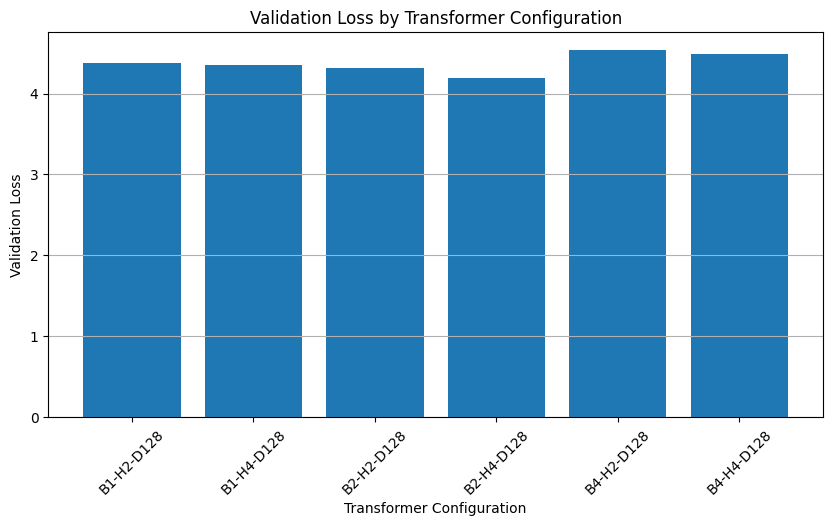

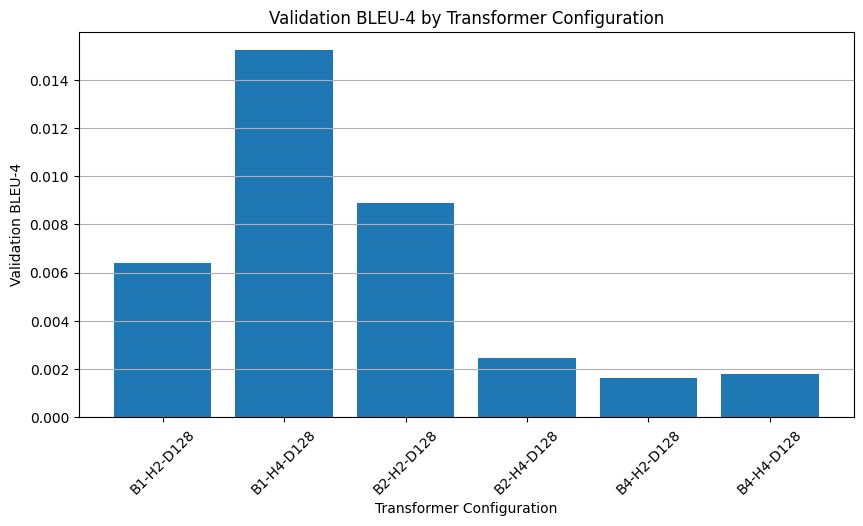

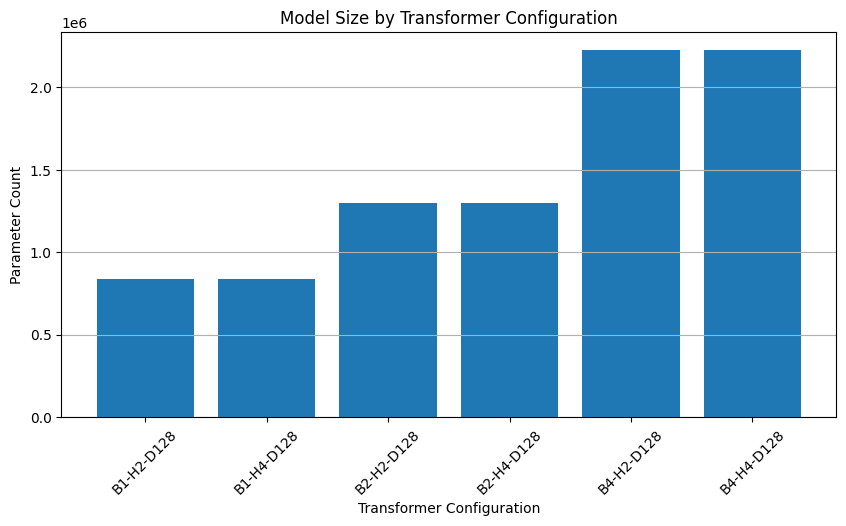

Best model: B1_H4_D128


,1
Blocks,1
Heads,4
Hidden Size,128
Training Loss,2.800443
Validation Loss,4.348994
Traditional Sequence Accuracy,0.0
Validation BLEU-4,0.015232
Training Time (sec),1.591609
Parameter Count,836201
Approx Complexity,O(1 * 25² * 128)


In [70]:
#Validation:
labels = [
    f"B{row['Blocks']}-H{row['Heads']}-D{row['Hidden Size']}"
    for _, row in translation_results_df.iterrows()
]

plt.figure(figsize=(10, 5))
plt.bar(labels, translation_results_df["Validation Loss"])
plt.xlabel("Transformer Configuration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss by Transformer Configuration")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

#BLEU
plt.figure(figsize=(10, 5))
plt.bar(labels, translation_results_df["Validation BLEU-4"])
plt.xlabel("Transformer Configuration")
plt.ylabel("Validation BLEU-4")
plt.title("Validation BLEU-4 by Transformer Configuration")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

#Parameter Count
plt.figure(figsize=(10, 5))
plt.bar(labels, translation_results_df["Parameter Count"])
plt.xlabel("Transformer Configuration")
plt.ylabel("Parameter Count")
plt.title("Model Size by Transformer Configuration")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

#Picks the best model
best_row = translation_results_df.sort_values(
    by="Validation BLEU-4",
    ascending=False
).iloc[0]

best_key = f"B{int(best_row['Blocks'])}_H{int(best_row['Heads'])}_D{int(best_row['Hidden Size'])}"
best_model = trained_translation_models[best_key]

print("Best model:", best_key)
best_row

Examples:

In [71]:
qualitative_results = []

for eng, true_fra in val_pairs[:10]:
    predicted_fra = translate_sentence(best_model, eng)

    exact_match = predicted_fra.strip() == true_fra.strip()
    bleu_score = simple_bleu_score(true_fra, predicted_fra)

    qualitative_results.append({
        "English Input": eng,
        "True French": true_fra,
        "Generated French": predicted_fra,
        "Exact Match": exact_match,
        "BLEU Score": bleu_score
    })

qualitative_df = pd.DataFrame(qualitative_results)
qualitative_df["BLEU Score"] = qualitative_df["BLEU Score"].round(4)

qualitative_df

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


,English Input,True French,Generated French,Exact Match,BLEU Score
0,he replies to all customer emails immediately,il répond immédiatement à tous les e-mails des...,il aime lire de la bibliothèque est très trop,False,0.0006
1,we work in the office,nous travaillons au bureau,nous avons visité le parc,False,0.0007
2,i want a large slice of chocolate cake,je veux une grande part de gâteau au chocolat,je veux une tasse de la fête un grand de la fê...,False,0.0210
3,they often talk about history,ils parlent souvent d'histoire,ils parlent souvent,False,0.0717
4,she translates text from english to french,elle traduit du texte de l'anglais au français,elle traduit des articles,False,0.0024
5,the weather forecast predicts heavy snow tomorrow,les prévisions météo annoncent de fortes chute...,le pain de la bibliothèque est très compétitif,False,0.0005
6,the store opens early in the morning,le magasin ouvre tôt le matin,les oiseaux le parc,False,0.0004
7,she wears a red dress,elle porte une robe rouge,elle a remporté une grande elle a de la biblio...,False,0.0007
8,he speaks six international languages complete...,il parle couramment six langues internationales,il parle couramment,False,0.0368
9,we are entirely ready to start the tournament,nous sommes entièrement prêts à commencer le t...,nous avons visité le pain,False,0.0004


##Problem 4:

Reverse Inputs:

In [72]:
ENG_PAD_IDX = eng_word_to_idx[PAD_TOKEN]
ENG_SOS_IDX = eng_word_to_idx[SOS_TOKEN]
ENG_EOS_IDX = eng_word_to_idx[EOS_TOKEN]

FRA_PAD_IDX = fra_word_to_idx[PAD_TOKEN]
FRA_SOS_IDX = fra_word_to_idx[SOS_TOKEN]
FRA_EOS_IDX = fra_word_to_idx[EOS_TOKEN]


class ReverseTranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        eng, fra = self.pairs[index]

        src = encode_sentence(fra, fra_word_to_idx)
        tgt = encode_sentence(eng, eng_word_to_idx)

        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


reverse_train_dataset = ReverseTranslationDataset(train_pairs)
reverse_val_dataset = ReverseTranslationDataset(val_pairs)

reverse_train_loader = DataLoader(
    reverse_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

reverse_val_loader = DataLoader(
    reverse_val_dataset,
    batch_size=batch_size,
    shuffle=False
)

New Model F2E:

In [73]:
class ReverseTransformerTranslator(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        hidden_size=128,
        num_heads=2,
        num_blocks=2,
        dropout=0.2
    ):
        super().__init__()

        self.hidden_size = hidden_size

        self.src_embedding = nn.Embedding(src_vocab_size, hidden_size)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, hidden_size)

        self.src_pos_encoding = TranslationPositionalEncoding(hidden_size)
        self.tgt_pos_encoding = TranslationPositionalEncoding(hidden_size)

        self.transformer = nn.Transformer(
            d_model=hidden_size,
            nhead=num_heads,
            num_encoder_layers=num_blocks,
            num_decoder_layers=num_blocks,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(hidden_size, tgt_vocab_size)

    def forward(self, src, tgt):
        src_padding_mask = src == FRA_PAD_IDX
        tgt_padding_mask = tgt == ENG_PAD_IDX

        tgt_seq_len = tgt.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_seq_len).to(device)

        src_embedded = self.src_embedding(src) * math.sqrt(self.hidden_size)
        tgt_embedded = self.tgt_embedding(tgt) * math.sqrt(self.hidden_size)

        src_embedded = self.src_pos_encoding(src_embedded)
        tgt_embedded = self.tgt_pos_encoding(tgt_embedded)

        output = self.transformer(
            src_embedded,
            tgt_embedded,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )

        output = self.fc_out(output)

        return output

def calculate_reverse_sequence_accuracy(predictions, targets):
    pred_tokens = torch.argmax(predictions, dim=-1)

    correct_sequences = 0
    total_sequences = targets.size(0)

    for pred, target in zip(pred_tokens, targets):
        mask = target != ENG_PAD_IDX

        if torch.equal(pred[mask], target[mask]):
            correct_sequences += 1

    return correct_sequences / total_sequences


def evaluate_reverse_translation_model(model, criterion):
    model.eval()

    total_loss = 0
    total_seq_acc = 0

    with torch.no_grad():
        for src, tgt in reverse_val_loader:
            src = src.to(device)
            tgt = tgt.to(device)

            decoder_input = tgt[:, :-1]
            decoder_target = tgt[:, 1:]

            output = model(src, decoder_input)

            loss = criterion(
                output.reshape(-1, eng_vocab_size),
                decoder_target.reshape(-1)
            )

            total_loss += loss.item()
            total_seq_acc += calculate_reverse_sequence_accuracy(
                output,
                decoder_target
            )

    return total_loss / len(reverse_val_loader), total_seq_acc / len(reverse_val_loader)

Translation Function:

In [74]:
def translate_french_to_english(model, sentence, max_len=MAX_LEN):
    model.eval()

    src = encode_sentence(sentence, fra_word_to_idx)
    src = torch.tensor(src, dtype=torch.long).unsqueeze(0).to(device)

    tgt_indices = [ENG_SOS_IDX]

    with torch.no_grad():
        for _ in range(max_len - 1):
            tgt_tensor = torch.tensor(tgt_indices, dtype=torch.long).unsqueeze(0).to(device)

            output = model(src, tgt_tensor)

            next_token = torch.argmax(output[:, -1, :], dim=-1).item()
            tgt_indices.append(next_token)

            if next_token == ENG_EOS_IDX:
                break

    return decode_tokens(tgt_indices, eng_idx_to_word)


def reverse_validation_bleu(model, sample_size=100):
    total_bleu = 0

    sample_pairs = val_pairs[:sample_size]

    for eng, fra in sample_pairs:
        prediction = translate_french_to_english(model, fra)
        total_bleu += simple_bleu_score(eng, prediction)

    return total_bleu / len(sample_pairs)

Training Functions:

In [75]:
def train_reverse_translation_model(
    hidden_size=128,
    num_heads=2,
    num_blocks=2,
    epochs=15,
    lr=0.001
):
    model = ReverseTransformerTranslator(
        src_vocab_size=fra_vocab_size,
        tgt_vocab_size=eng_vocab_size,
        hidden_size=hidden_size,
        num_heads=num_heads,
        num_blocks=num_blocks
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=ENG_PAD_IDX)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for src, tgt in reverse_train_loader:
            src = src.to(device)
            tgt = tgt.to(device)

            decoder_input = tgt[:, :-1]
            decoder_target = tgt[:, 1:]

            optimizer.zero_grad()

            output = model(src, decoder_input)

            loss = criterion(
                output.reshape(-1, eng_vocab_size),
                decoder_target.reshape(-1)
            )

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(reverse_train_loader)

        val_loss, val_acc = evaluate_reverse_translation_model(model, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Seq Acc: {val_acc:.4f}"
        )

    training_time = time.time() - start_time

    final_val_loss, final_seq_acc = evaluate_reverse_translation_model(model, criterion)
    bleu = reverse_validation_bleu(model, sample_size=100)

    results = {
        "Blocks": num_blocks,
        "Heads": num_heads,
        "Hidden Size": hidden_size,
        "Training Loss": train_losses[-1],
        "Validation Loss": final_val_loss,
        "Traditional Sequence Accuracy": final_seq_acc,
        "Validation BLEU-4": bleu,
        "Training Time (sec)": training_time,
        "Parameter Count": count_parameters(model),
        "Approx Complexity": translation_complexity(MAX_LEN, hidden_size, num_blocks)
    }

    return model, train_losses, val_losses, val_accuracies, results

Different Configurations:

In [78]:
reverse_translation_configs = [
    {"num_blocks": 1, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 1, "num_heads": 4, "hidden_size": 128},
    {"num_blocks": 2, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 2, "num_heads": 4, "hidden_size": 128},
    {"num_blocks": 4, "num_heads": 2, "hidden_size": 128},
    {"num_blocks": 4, "num_heads": 4, "hidden_size": 128},

]

all_reverse_results = []
trained_reverse_models = {}

for config in reverse_translation_configs:
    print("\nTraining French-to-English configuration:", config)

    model, train_losses, val_losses, val_accs, results = train_reverse_translation_model(
        hidden_size=config["hidden_size"],
        num_heads=config["num_heads"],
        num_blocks=config["num_blocks"],
        epochs=15,
        lr=0.001
    )

    key = f"B{config['num_blocks']}_H{config['num_heads']}_D{config['hidden_size']}"
    trained_reverse_models[key] = model

    all_reverse_results.append(results)

reverse_results_df = pd.DataFrame(all_reverse_results)
reverse_results_df

reverse_results_df.sort_values(
    by="Validation BLEU-4",
    ascending=False
)


Training French-to-English configuration: {'num_blocks': 1, 'num_heads': 2, 'hidden_size': 128}
Epoch 1/15 | Train Loss: 6.2123 | Val Loss: 5.6425 | Seq Acc: 0.0000
Epoch 2/15 | Train Loss: 5.5304 | Val Loss: 5.4152 | Seq Acc: 0.0000
Epoch 3/15 | Train Loss: 5.2527 | Val Loss: 5.2508 | Seq Acc: 0.0000
Epoch 4/15 | Train Loss: 4.9847 | Val Loss: 5.1100 | Seq Acc: 0.0000
Epoch 5/15 | Train Loss: 4.7317 | Val Loss: 4.9760 | Seq Acc: 0.0000
Epoch 6/15 | Train Loss: 4.4696 | Val Loss: 4.8406 | Seq Acc: 0.0000
Epoch 7/15 | Train Loss: 4.2182 | Val Loss: 4.6816 | Seq Acc: 0.0000
Epoch 8/15 | Train Loss: 3.9888 | Val Loss: 4.5773 | Seq Acc: 0.0000
Epoch 9/15 | Train Loss: 3.7724 | Val Loss: 4.5379 | Seq Acc: 0.0000
Epoch 10/15 | Train Loss: 3.5660 | Val Loss: 4.4406 | Seq Acc: 0.0000
Epoch 11/15 | Train Loss: 3.3820 | Val Loss: 4.3890 | Seq Acc: 0.0000
Epoch 12/15 | Train Loss: 3.2018 | Val Loss: 4.3148 | Seq Acc: 0.0000
Epoch 13/15 | Train Loss: 3.0154 | Val Loss: 4.2888 | Seq Acc: 0.0000
Ep

,Blocks,Heads,Hidden Size,Training Loss,Validation Loss,Traditional Sequence Accuracy,Validation BLEU-4,Training Time (sec),Parameter Count,Approx Complexity
3,2,4,128,2.716640,3.958665,0.0,0.024569,2.349670,1286407,O(2 * 25² * 128)
0,1,2,128,2.720698,4.252258,0.0,0.023879,1.621433,823559,O(1 * 25² * 128)
1,1,4,128,2.639399,4.271555,0.0,0.021791,1.571036,823559,O(1 * 25² * 128)
4,4,2,128,3.529894,4.340898,0.0,0.014139,4.026227,2212103,O(4 * 25² * 128)
2,2,2,128,2.738976,4.133156,0.0,0.009796,2.411551,1286407,O(2 * 25² * 128)
5,4,4,128,3.624446,4.340157,0.0,0.005197,4.028219,2212103,O(4 * 25² * 128)


Results:


Training French-to-English configuration: {'num_blocks': 1, 'num_heads': 2, 'hidden_size': 128}
Epoch 1/15 | Train Loss: 6.3552 | Val Loss: 5.7362 | Seq Acc: 0.0000


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 2/15 | Train Loss: 5.5936 | Val Loss: 5.5012 | Seq Acc: 0.0000
Epoch 3/15 | Train Loss: 5.2662 | Val Loss: 5.3529 | Seq Acc: 0.0000
Epoch 4/15 | Train Loss: 4.9848 | Val Loss: 5.1644 | Seq Acc: 0.0000
Epoch 5/15 | Train Loss: 4.7429 | Val Loss: 4.9749 | Seq Acc: 0.0000
Epoch 6/15 | Train Loss: 4.4946 | Val Loss: 4.8152 | Seq Acc: 0.0000
Epoch 7/15 | Train Loss: 4.2362 | Val Loss: 4.6785 | Seq Acc: 0.0000
Epoch 8/15 | Train Loss: 4.0081 | Val Loss: 4.5510 | Seq Acc: 0.0000
Epoch 9/15 | Train Loss: 3.7712 | Val Loss: 4.4869 | Seq Acc: 0.0000
Epoch 10/15 | Train Loss: 3.5696 | Val Loss: 4.4296 | Seq Acc: 0.0000
Epoch 11/15 | Train Loss: 3.3753 | Val Loss: 4.3718 | Seq Acc: 0.0000
Epoch 12/15 | Train Loss: 3.1991 | Val Loss: 4.3141 | Seq Acc: 0.0000
Epoch 13/15 | Train Loss: 3.0268 | Val Loss: 4.3003 | Seq Acc: 0.0000
Epoch 14/15 | Train Loss: 2.8730 | Val Loss: 4.2327 | Seq Acc: 0.0000
Epoch 15/15 | Train Loss: 2.7060 | Val Loss: 4.2299 | Seq Acc: 0.0000

Training French-to-English 

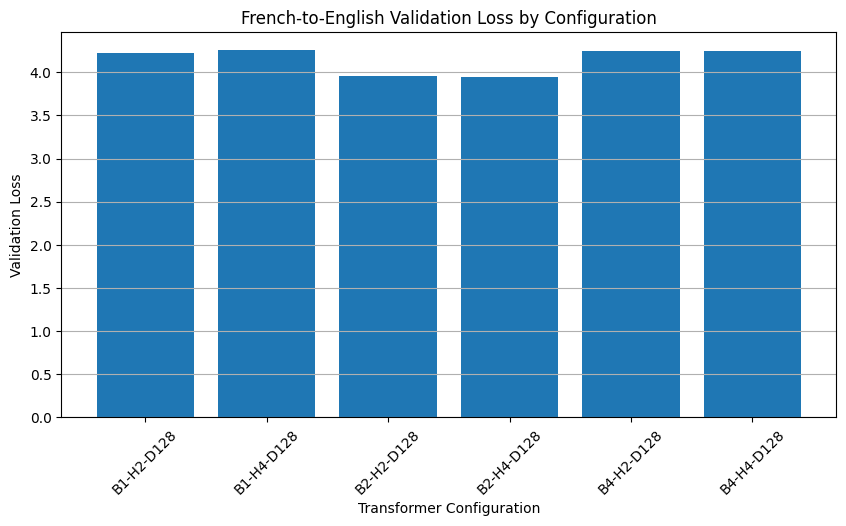

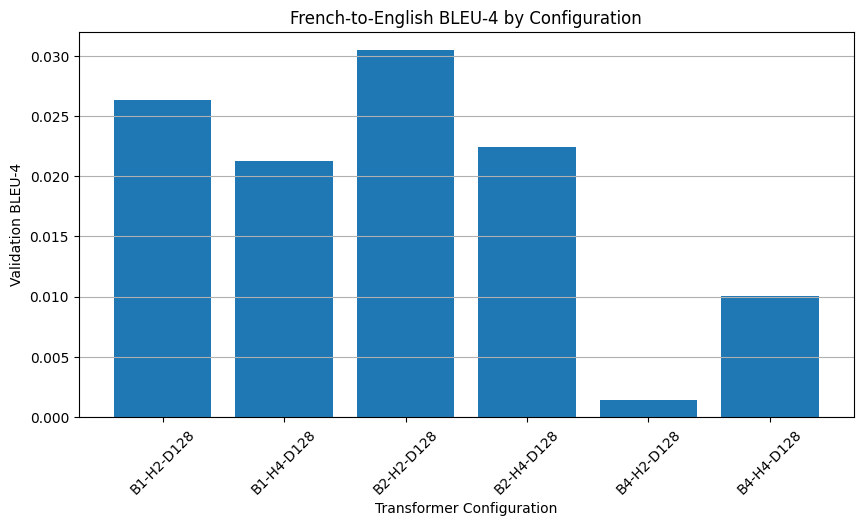

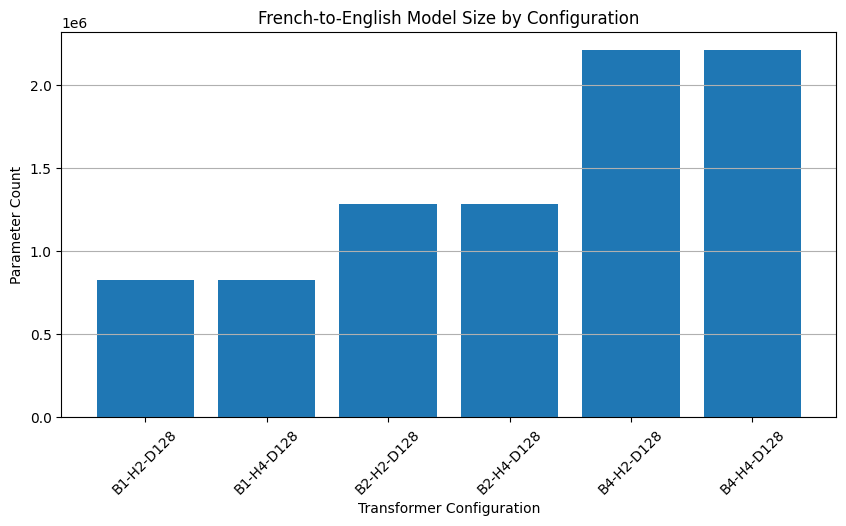

Best French-to-English model: B2_H2_D128


,2
Blocks,2
Heads,2
Hidden Size,128
Training Loss,2.747492
Validation Loss,3.956926
Traditional Sequence Accuracy,0.0
Validation BLEU-4,0.030451
Training Time (sec),2.363293
Parameter Count,1286407
Approx Complexity,O(2 * 25² * 128)


In [77]:
all_reverse_results = []
trained_reverse_models = {}

for config in reverse_translation_configs:
    print("\nTraining French-to-English configuration:", config)

    model, train_losses, val_losses, val_accs, results = train_reverse_translation_model(
        hidden_size=config["hidden_size"],
        num_heads=config["num_heads"],
        num_blocks=config["num_blocks"],
        epochs=15,
        lr=0.001
    )

    key = f"B{config['num_blocks']}_H{config['num_heads']}_D{config['hidden_size']}"
    trained_reverse_models[key] = model

    all_reverse_results.append(results)


reverse_results_df = pd.DataFrame(all_reverse_results)
reverse_results_df

reverse_results_df.sort_values(
    by="Validation BLEU-4",
    ascending=False
)

#Validation Loss
reverse_labels = [
    f"B{row['Blocks']}-H{row['Heads']}-D{row['Hidden Size']}"
    for _, row in reverse_results_df.iterrows()
]

plt.figure(figsize=(10, 5))
plt.bar(reverse_labels, reverse_results_df["Validation Loss"])
plt.xlabel("Transformer Configuration")
plt.ylabel("Validation Loss")
plt.title("French-to-English Validation Loss by Configuration")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

#BLEU-4
plt.figure(figsize=(10, 5))
plt.bar(reverse_labels, reverse_results_df["Validation BLEU-4"])
plt.xlabel("Transformer Configuration")
plt.ylabel("Validation BLEU-4")
plt.title("French-to-English BLEU-4 by Configuration")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

#Parameter Count
plt.figure(figsize=(10, 5))
plt.bar(reverse_labels, reverse_results_df["Parameter Count"])
plt.xlabel("Transformer Configuration")
plt.ylabel("Parameter Count")
plt.title("French-to-English Model Size by Configuration")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

#Finding Best Model
best_reverse_row = reverse_results_df.sort_values(
    by="Validation BLEU-4",
    ascending=False
).iloc[0]

best_reverse_key = (
    f"B{int(best_reverse_row['Blocks'])}_"
    f"H{int(best_reverse_row['Heads'])}_"
    f"D{int(best_reverse_row['Hidden Size'])}"
)

best_reverse_model = trained_reverse_models[best_reverse_key]

print("Best French-to-English model:", best_reverse_key)
best_reverse_row

Example Sentence:

In [62]:
reverse_qualitative_results = []

for eng, true_fra in val_pairs[:10]:
    generated_eng = translate_french_to_english(best_reverse_model, true_fra)

    exact_match = generated_eng.strip() == eng.strip()
    bleu_score = simple_bleu_score(eng, generated_eng)

    reverse_qualitative_results.append({
        "French Input": true_fra,
        "True English": eng,
        "Generated English": generated_eng,
        "Exact Match": exact_match,
        "BLEU Score": bleu_score
    })

reverse_qualitative_df = pd.DataFrame(reverse_qualitative_results)
reverse_qualitative_df["BLEU Score"] = reverse_qualitative_df["BLEU Score"].round(4)

reverse_qualitative_df

,French Input,True English,Generated English,Exact Match,BLEU Score
0,il répond immédiatement à tous les e-mails des...,he replies to all customer emails immediately,he writes to drink,False,0.0004
1,nous travaillons au bureau,we work in the office,we are going to the national,False,0.0008
2,je veux une grande part de gâteau au chocolat,i want a large slice of chocolate cake,i want to drink a new cup of of of of of of of...,False,0.0029
3,ils parlent souvent d'histoire,they often talk about history,they speak often talk about,False,0.0604
4,elle traduit du texte de l'anglais au français,she translates text from english to french,she translates,False,0.0008
5,les prévisions météo annoncent de fortes chute...,the weather forecast predicts heavy snow tomorrow,i will,False,0.0000
6,le magasin ouvre tôt le matin,the store opens early in the morning,the birds the birds is melting,False,0.0006
7,elle porte une robe rouge,she wears a red dress,she won a beautiful,False,0.0007
8,il parle couramment six langues internationales,he speaks six international languages complete...,he speaks five languages fluently,False,0.0045
9,nous sommes entièrement prêts à commencer le t...,we are entirely ready to start the tournament,we are going to the park every morning,False,0.0052
